In [31]:
import os
# import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt   
from matplotlib.lines import Line2D

# from matplotlib.colors import ListedColormap, BoundaryNorm
%matplotlib inline

In [ ]:
# Define the path to the data folders relative to the notebook
current_dir = os.getcwd()  # Get the current working directory

# Define paths for data loading
input_path = os.path.join(current_dir, '../data/')

# Define path for saving figures
output_path = os.path.join(current_dir, '../figs/')


# Define the file name (same for both folders)
file_strict = 'data_choice_evaluation_strict.csv'
file_not_strict = 'data_choice_evaluation_not_strict.csv'

# Load the CSV file
df_strict = pd.read_csv(os.path.join(input_path, file_strict))
df_less_strict = pd.read_csv(os.path.join(input_path, file_not_strict))

In [33]:
# Create copies of the dataframes for data manipulation
data_strict = df_strict.copy()
data_less_strict = df_less_strict.copy()

# Remove the 'Unemployment' question from both datasets
data_strict = data_strict[data_strict['question'] != 'Unemployment']
data_less_strict = data_less_strict[data_less_strict['question'] != 'Unemployment']

In [34]:
data_strict

,participant_id,frame,question,main,follow_up,choice,evaluation
0,0,loss,Disease,True,NaN,1,22
2,0,loss,Painting,True,NaN,1,73
3,0,loss,Virus,True,NaN,1,40
4,1,loss,Disease,True,NaN,2,30
5,1,loss,Disease,NaN,True,0,28
...,...,...,...,...,...,...,...
2133,683,gain,Painting,NaN,True,0,100
2134,683,gain,Virus,True,NaN,0,99
2135,686,gain,Disease,True,NaN,0,61
2137,686,gain,Painting,True,NaN,0,70


# II. Visualization function

In [39]:
def visualize_choice_distribution(df, questions=None, task=None, frames=None,
                                color_mapping=None, label_mapping=None,
                                count_column='count', figsize=(20, 8),
                                alpha=0.7, return_fig=False):
    """
    Create a single row of bar plots showing choice distributions by question.
    """
    # Defaults
    if questions is None: questions = ['Disease', 'Painting', 'Virus']
    if frames is None: frames = ['gain', 'loss']
    
    # 1. Data Preparation
    data = df[df[task] == True].copy()
    
    # Calculate frequencies and proportions in one go
    df_freq = data.groupby(['frame', 'question', 'choice']).size().reset_index(name=count_column)
    total_counts = data.groupby(['frame', 'question'])['choice'].count().reset_index(name='total_count')
    df_freq = pd.merge(df_freq, total_counts, on=['frame', 'question'])
    df_freq['proportion'] = df_freq[count_column] / df_freq['total_count'] * 100
    
    # Setup Plot
    fig, axs = plt.subplots(1, len(questions), figsize=figsize)
    axs = np.atleast_1d(axs) # Ensures axs is always a list/array
    
    all_choices = sorted(data['choice'].astype(str).unique())
    num_choices = len(all_choices)
    bar_width = 0.3
    center_offset = (num_choices - 1) / 2

    # 2. Plotting Loop
    for col, question in enumerate(questions):
        ax = axs[col]
        
        # Lists to store plotting data for this subplot
        x_positions, heights, colors, counts = [], [], [], []
        
        # Collect data for all bars in this question
        for i, frame in enumerate(frames):
            for j, choice in enumerate(all_choices):
                # Filter once
                subset = df_freq[
                    (df_freq['question'] == question) & 
                    (df_freq['choice'].astype(str) == choice) & 
                    (df_freq['frame'] == frame)
                ]
                
                if not subset.empty:
                    # Calculate position centered around integer i
                    pos = i + (j - center_offset) * bar_width
                    
                    x_positions.append(pos)
                    heights.append(subset['proportion'].values[0])
                    counts.append(subset[count_column].values[0])
                    colors.append(color_mapping[frame][choice])

        # Plot bars
        ax.bar(x_positions, heights, width=bar_width*0.9, color=colors, 
               edgecolor='black', linewidth=1, alpha=alpha)
        
        # Add Annotations (Percentage and Count)
        for x, h, c in zip(x_positions, heights, counts):
            ax.text(x, h, f'{h:.1f}%', ha='center', va='bottom', fontsize=14, color='black')
            ax.text(x, 2, f'n={c}', ha='center', va='center', fontsize=14, color='black')
            
        # 3. Axis Formatting
        # Use standard ticks, but add padding to move labels down
        ax.set_xticks(range(len(frames)))
        x_labels = [label_mapping.get(f, f) for f in frames] if label_mapping else frames
        ax.set_xticklabels(x_labels, fontsize=18)
        ax.tick_params(axis='x', pad=10) # Moves labels down cleanly
        ax.tick_params(axis='y', labelsize=18)
        
        # Titles
        title_map = {'Virus': 'Computer Virus', 'Painting': 'Damaged Painting'}
        ax.set_title(title_map.get(question, question), fontsize=24)
        
        if col == 0:
            ax.set_ylabel('Proportion (%)', fontsize=24)
        
        ax.set_ylim(0, 100)
        ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    # 4. Legend
    # Get colors from 'gain' mapping, fallback to 'loss' or gray
    choice_colors = []
    for c in all_choices:
        color = color_mapping.get('gain', {}).get(c) or color_mapping.get('loss', {}).get(c) or 'gray'
        choice_colors.append(color)
        
    choice_labels = [label_mapping.get(c, c) for c in all_choices] if label_mapping else all_choices
    handles = [Line2D([0], [0], color=c, lw=8) for c in choice_colors]
    
    axs[-1].legend(handles=handles, labels=choice_labels, loc='upper left', 
                    bbox_to_anchor=(1.02, 1), fontsize=16, frameon=False)

    fig.text(0.5, 0.01, 'Frame', ha='center', fontsize=24)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    
    # Return or display the figure
    if return_fig:
        return fig
    else:
        plt.show()

In [40]:
# Define color mapping for main questions
color_mapping_main = {
    'gain': {'0': '#a6cee3', '1': '#fdbf6f', '2': '#D3D3D3'},
    'loss': {'0': '#1f78b4', '1': '#ff7f00', '2': '#505050'}
}
# ["#a6cee3", "#1f78b4", "#fdbf6f", "#ff7f00", "#D3D3D3", "#505050"]
label_mapping_main = {'0': 'sure', '1': 'risky', '2': 'neutral'}


# Define color mapping for binary questions
color_mapping_follow = {
    'gain': {'0': '#a6cee3', '1': '#fdbf6f'},
    'loss': {'0': '#1f78b4', '1': '#ff7f00'}
}
# ["#a6cee3", "#1f78b4", "#fdbf6f", "#ff7f00", "#D3D3D3", "#505050"]
label_mapping_follow = {'0': 'sure', '1': 'risky'}

## 1. Strict Dataset

### 1.1 Ternary choice

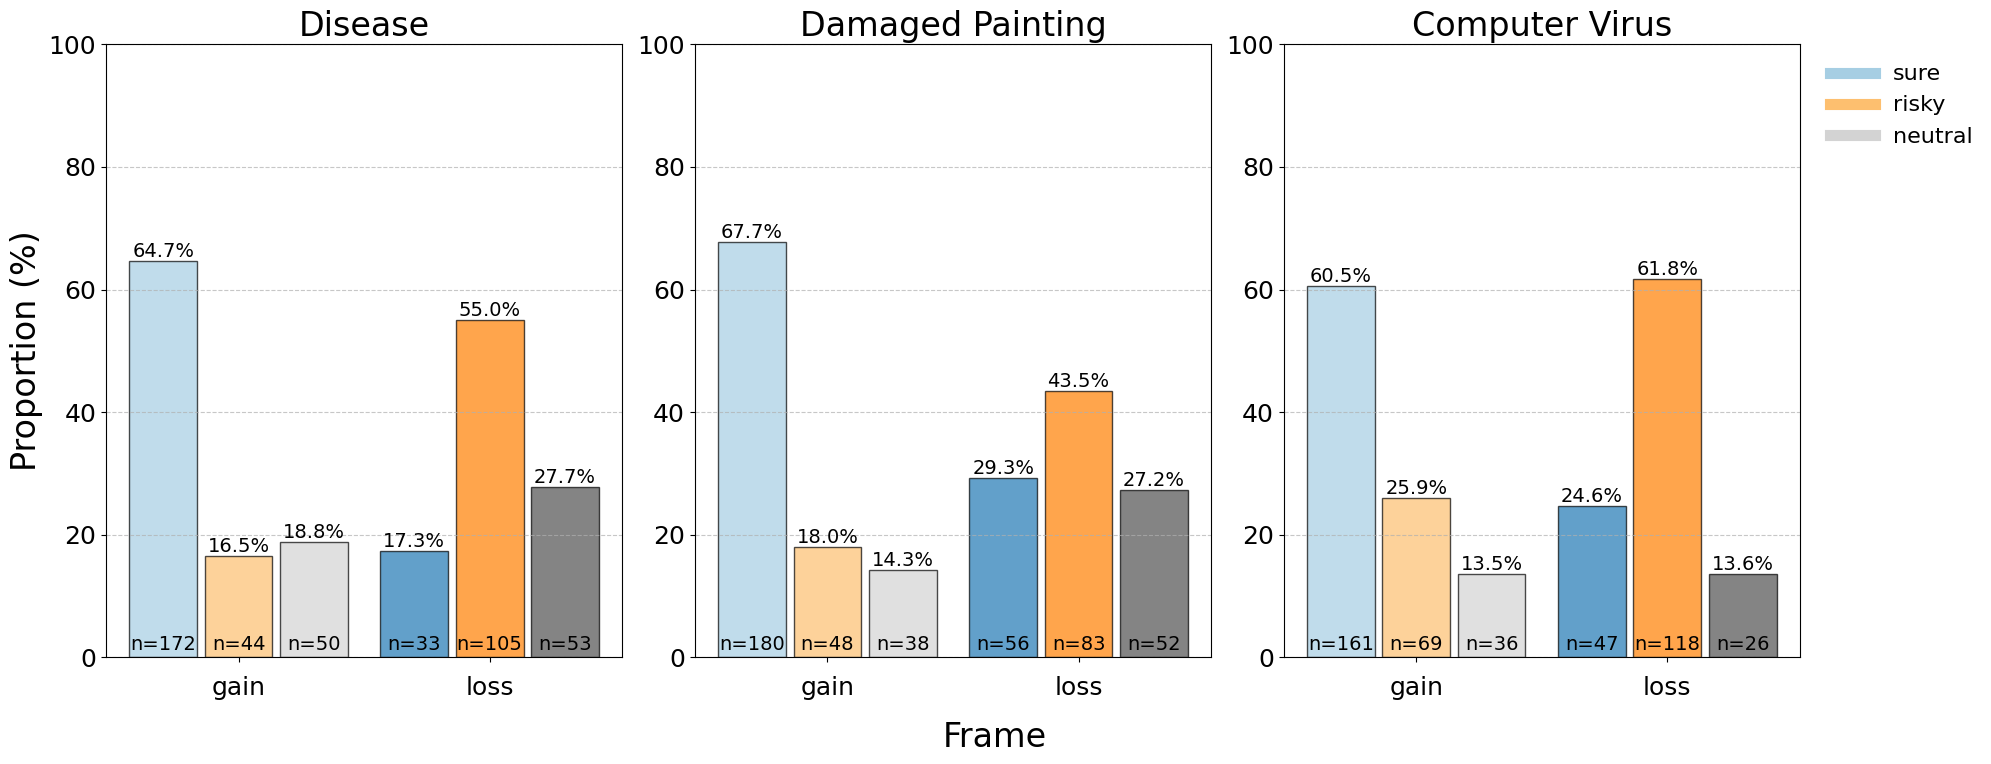

In [41]:
# Plot with the modified function
fig = visualize_choice_distribution(
    data_strict,
    color_mapping=color_mapping_main,
    label_mapping=label_mapping_main,
    task='main',
    return_fig=True
)

In [42]:
# Save the figure
fig.savefig(os.path.join(output_path, 'choice_distribution_main_strict.png'), bbox_inches='tight', dpi=300)

### 1.2 Binary Choice

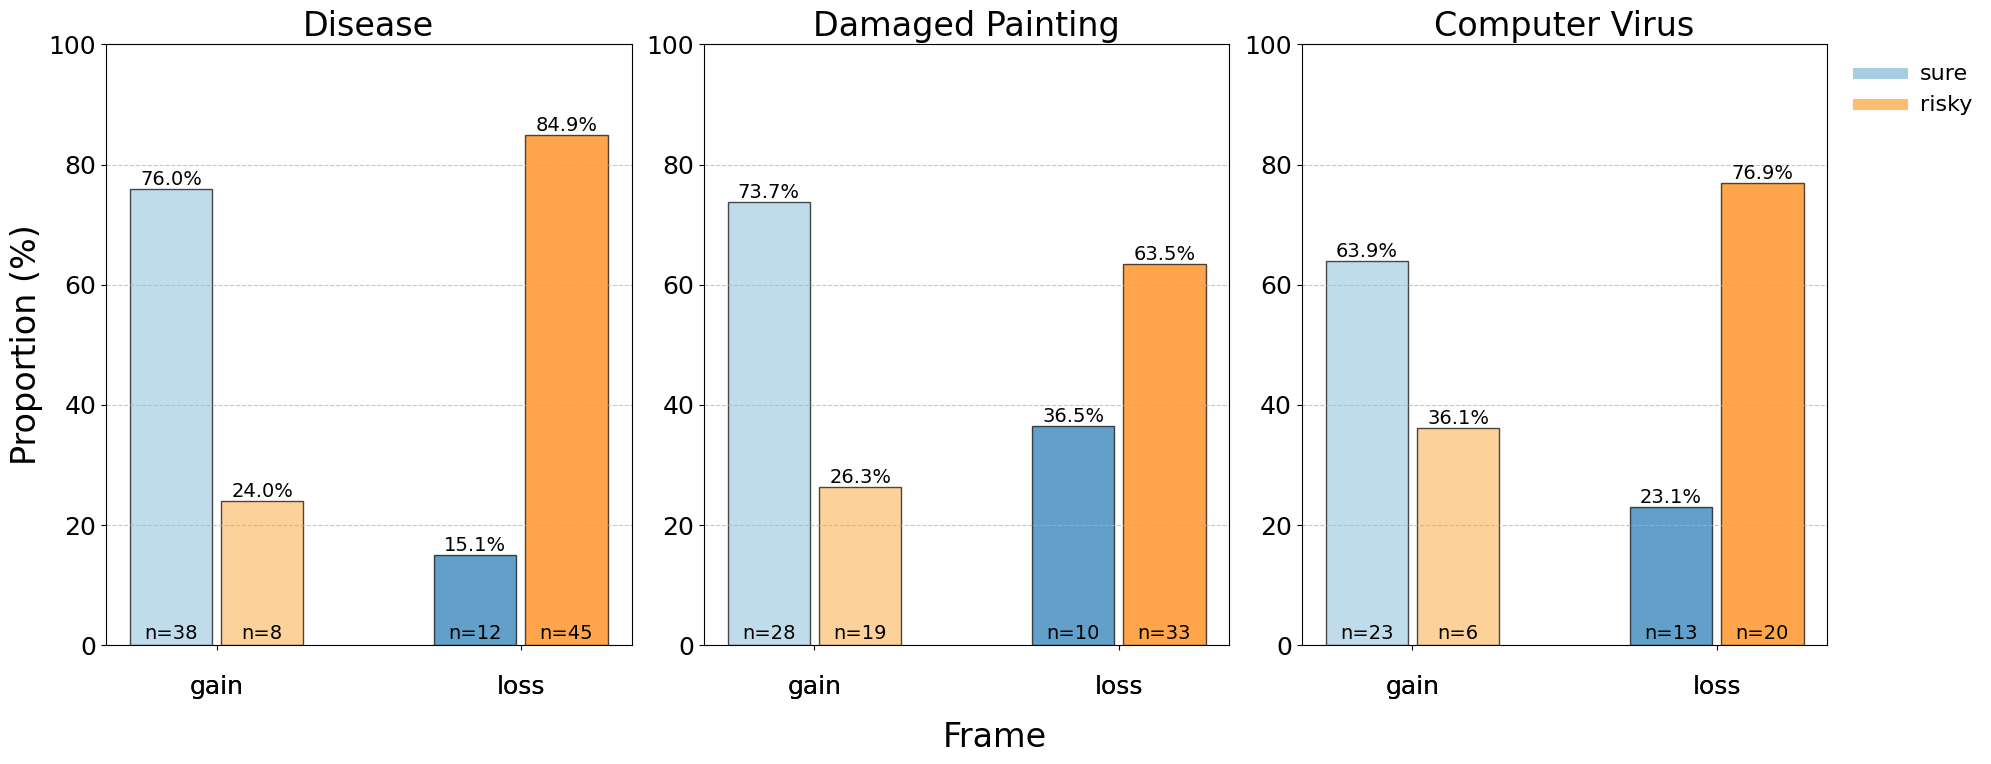

In [ ]:
# Plot with the modified function
fig = visualize_choice_distribution(
    data_strict,
    color_mapping=color_mapping_follow,
    label_mapping=label_mapping_follow,
    task='follow_up',
    return_fig=True
)

In [ ]:
# Save the figure
fig.savefig(os.path.join(output_path, 'choice_distribution_follow_strict.png'), bbox_inches='tight', dpi=300)

## 2. Less Strict 

### 2.1 Ternary Choice

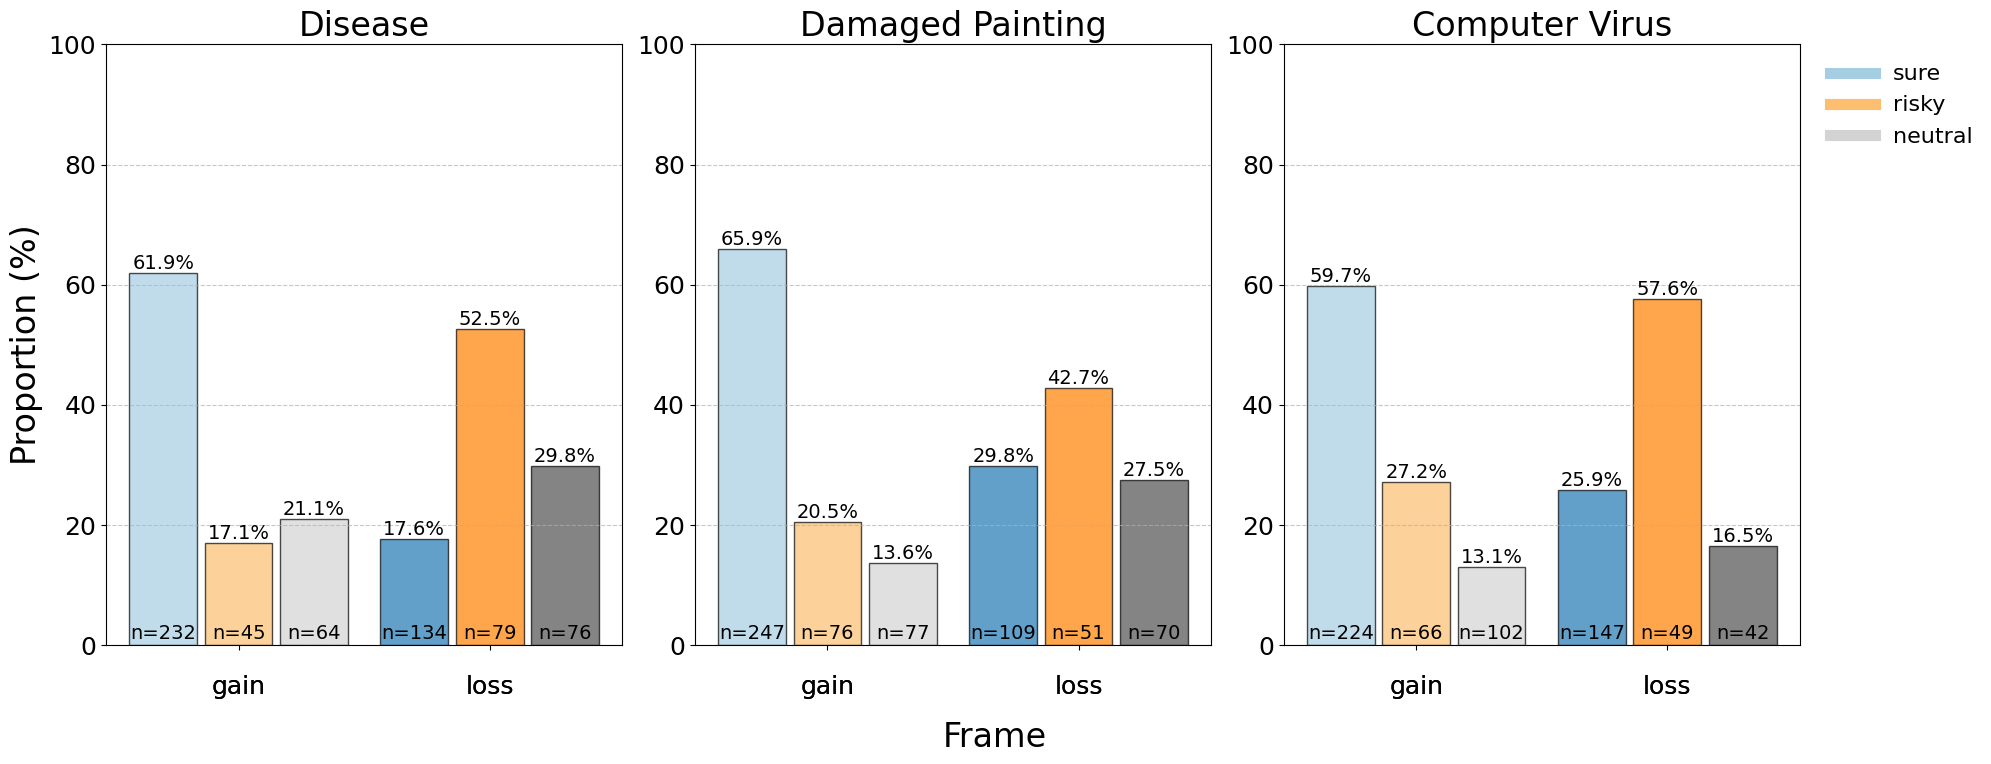

In [ ]:
# Plot with the modified function
fig = visualize_choice_distribution(
    data_less_strict,
    color_mapping=color_mapping_main,
    label_mapping=label_mapping_main,
    task='main',
    return_fig=True
)

In [ ]:
# Save the figure
fig.savefig(os.path.join(output_path, 'choice_distribution_main_less_strict.png'), bbox_inches='tight', dpi=300)

### 2.2 Binary Choice

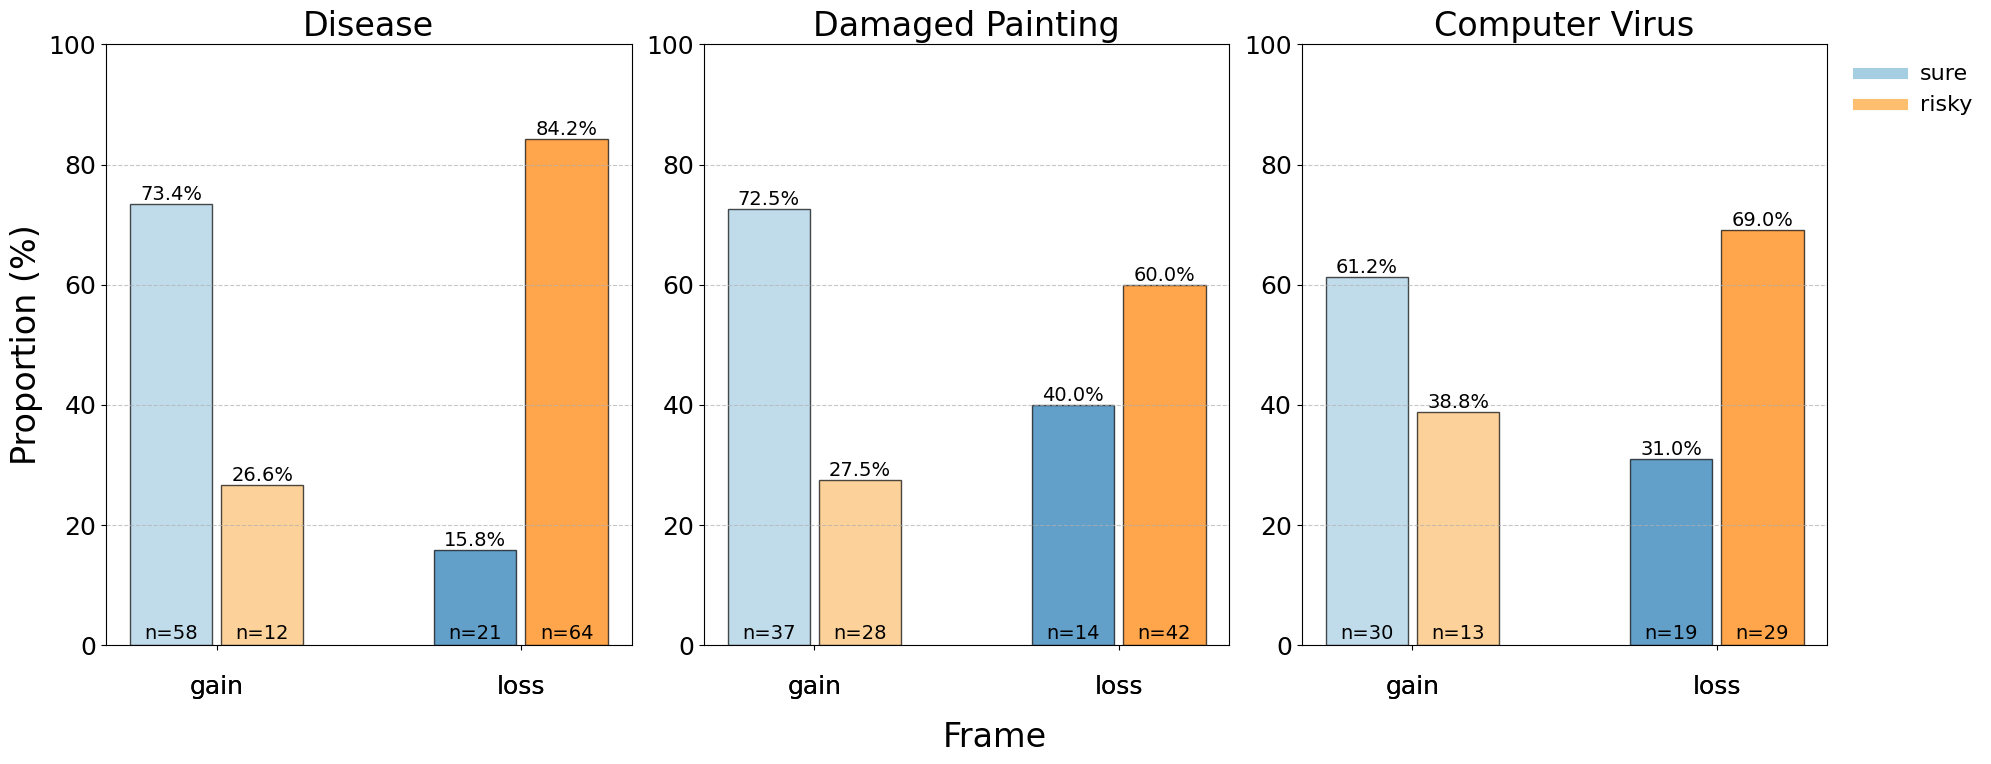

In [ ]:
# Plot with the modified function
fig = visualize_choice_distribution(
    data_less_strict,
    color_mapping=color_mapping_main,
    label_mapping=label_mapping_main,
    task='follow_up',
    return_fig=True
)

In [ ]:
# Save the figure
fig.savefig(os.path.join(output_path, 'choice_distribution_follow_less_strict.png'), bbox_inches='tight', dpi=300)